In [3]:
import src.util.functions as functions

In [3]:
import numpy as np

# ------------------------------------------------------------------
def PLSCurrent(C, t_max, rng=np.random.default_rng()):
    """
    Return I_func(t) that produces a rectangular-pulse current profile.

    • pulses_per_hour ∈ [1, 10]   (uniform)
    • All pulses in one sample share ONE peak: ±(0.5‒1)·C.
    • Width is a fixed fraction (5‒30 %) of the period → typically 2-30 s.
    """
    pulses_per_hour = rng.integers(1, 11)                    # 1–10 pulses / h
    n_pulses = max(1, int(pulses_per_hour * t_max / 3600))   # fit into t_max

    direction = rng.choice([1, -1])                          # charge or discharge
    peak = direction * C * rng.uniform(0.5, 1.0)             # fixed amplitude

    period = t_max / n_pulses
    duty_cycle = rng.uniform(0.1, 0.7)                     # 10–30 %
    pulse_width = period * duty_cycle                        # hold-time in s

    starts = np.arange(n_pulses) * period                    # equally spaced

    def I_func(t):
        t = np.asarray(t)
        I = np.zeros_like(t, dtype=float)
        for st in starts:
            on = (t >= st) & (t < st + pulse_width)          # rectangular gate
            I[on] = peak
        return I

    return I_func
# ------------------------------------------------------------------

def make_currents(family, C, t_max, t, num, rng=np.random.default_rng()):
    I_list = []

    if family == "GRF":
        for _ in range(num):
            s = rng.integers(0, 2**31 - 1)
            I_func = functions.GaussianRFCurrent(s, C, t_max)
            I_list.append(I_func(t))

    elif family == "Triangle":
        for _ in range(num):
            value = rng.uniform(-1, 1)
            I_func = functions.TriangleCurrent(value * C)
            I_list.append(I_func(t))

    elif family == "CC":
        for _ in range(num):
            value = rng.uniform(-1, 1)
            I_func = functions.ConstantCurrent(value * C)
            I_list.append(I_func(t))

    elif family == "PLS":                                     # ← new branch
        for _ in range(num):
            I_func = PLSCurrent(C, t_max, rng)
            I_list.append(I_func(t))

    else:
        raise ValueError(f"Unknown family: {family}")

    return I_list


In [5]:
t_max = 3600          # seconds
t = np.linspace(0, t_max, 3600)
I_samples = make_currents("PLS", C=1.0, t_max=t_max, t=t, num=5)


In [6]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'Time (s)')

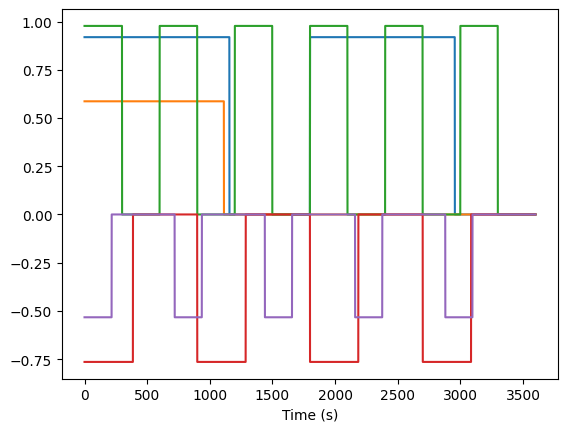

In [7]:
plt.plot(I_samples[0], label="Sample 1")
plt.plot(I_samples[1], label="Sample 2")
plt.plot(I_samples[2], label="Sample 3")
plt.plot(I_samples[3], label="Sample 4")
plt.plot(I_samples[4], label="Sample 5")
plt.xlabel("Time (s)")

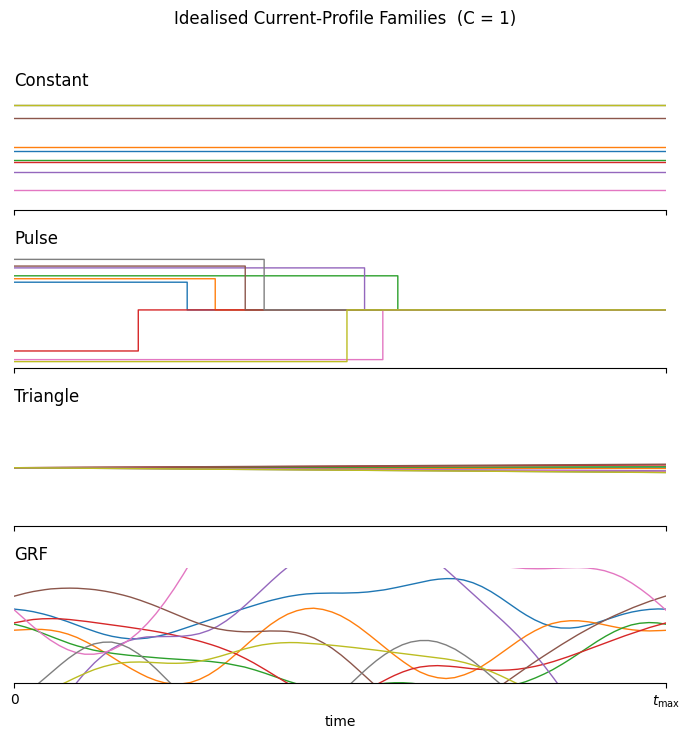

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# globals (unchanged)
# -----------------------------------------------------------
C       = 1.0
t_max   = 100.0
t       = np.linspace(0, t_max, 1000)
num     = 9                       # traces per family
seeds   = dict(CC=1, PLS=2, Triangle=3, GRF=4)
families = ["CC", "PLS", "Triangle", "GRF"]

# -----------------------------------------------------------
# helper: peak amplitude for symmetric ordering
# -----------------------------------------------------------
def _amplitude(trace):
    return np.max(np.abs(trace))

# -----------------------------------------------------------
# plotting
# -----------------------------------------------------------
fig, axes = plt.subplots(len(families), 1,
                         figsize=(7, 1.8 * len(families)),
                         sharex=True, sharey=True)

for ax, fam in zip(axes, families):
    # ----- generate traces with the *new* function -------------
    rng     = np.random.default_rng(seeds[fam])          # reproducible
    traces  = make_currents(fam, C, t_max, t, num, rng)  # <<<< changed line
    traces  = np.asarray(traces)

    # ----- symmetric sorting (visual nicety) -------------------
    order   = np.argsort([_amplitude(tr) for tr in traces])
    traces  = traces[order]

    # ----- draw ------------------------------------------------
    if fam == "PLS":
        for tr in traces:
            ax.step(t, tr, where='post', lw=1)
    else:
        for tr in traces:
            ax.plot(t, tr, lw=1)

    # ----- cosmetics ------------------------------------------
    ax.set_xlim(0, t_max)
    ax.set_ylim(-1.1 * C, 1.1 * C)
    ax.set_xticks([0, t_max])
    ax.set_xticklabels(['0', r'$t_{\mathrm{max}}$'])
    ax.set_yticks([])

    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)

    names = dict(CC='Constant', PLS='Pulse', Triangle='Triangle', GRF='GRF')
    ax.set_title(names[fam], loc='left')

axes[-1].set_xlabel('time')
fig.suptitle('Idealised Current-Profile Families  (C = 1)', y=1.02)
fig.tight_layout()
plt.show()
